이 자료는 위키독스 딥 러닝을 이용한 자연어 처리 입문의 네이버 쇼핑 리뷰 분류하기의 튜토리얼입니다.

링크 : https://wikidocs.net/94600

# 1. Colab에 한국어 형태소분석기 설치

- kiwipiepy

In [1]:
%pip install kiwipiepy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.5/35.5 MB 46.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 128.3 MB/s eta 0:00:00
  Created wheel for kiwipiepy_model: filename=kiwipiepy_model-0.21.0-py3-none-any.whl size=35593192 sha256=a6e93220491c3dd935531b67bbcb45517baf6571071ea73dd669536a5a41d799
  Stored in directory: /root/.cache/pip/wheels/5f/94/81/3e8b1478625f1bdb3b72733dfe3086a8f77a8f25db2b1d746b
Successfully built kiwipiepy_model


# 2. 네이버 쇼핑 리뷰 데이터에 대한 이해와 전처리

| 모듈                 | 핵심 용도                             |
| ------------------ | --------------------------------- |
| `re`               | 텍스트 정제(특수문자/불필요한 기호 제거)           |
| `pandas`           | 데이터 읽기/전처리(DataFrame)             |
| `numpy`            | 수치 연산, 벡터/행렬 처리                   |
| `matplotlib`       | 성능 곡선·분포 그래프 시각화                  |
| `urllib.request`   | 원격 데이터 다운로드                       |
| `WordCloud`        | 자주 쓰인 단어를 이미지로 시각화                |
| `train_test_split` | 데이터셋 분할(재현성 위해 `random_state` 권장) |
| `Tokenizer`        | 단어 사전 구축, 정수 인코딩                  |
| `pad_sequences`    | 입력 길이 통일(짧으면 0 채움, 길면 자름)         |


In [2]:
# ============================================
# 📦 텍스트 분류 실습에 필요한 라이브러리 로드
# ============================================

import re                           # 정규표현식: 텍스트 정제(특수문자/숫자 제거 등)
import pandas as pd                 # 표 형태 데이터 로드/가공 (CSV, TSV 등)
import numpy as np                  # 수치 계산과 배열 연산
import matplotlib.pyplot as plt     # 시각화 (막대그래프, 추세선 등)
import urllib.request               # 웹에서 데이터 파일 다운로드

from wordcloud import WordCloud     # 단어 빈도를 이미지로 시각화(워드클라우드)
from sklearn.model_selection import train_test_split
# train_test_split: 학습/검증(또는 테스트) 데이터 분리

from tensorflow.keras.preprocessing.text import Tokenizer
# Tokenizer: 텍스트 → 정수 시퀀스 변환(단어 사전 구축)

from tensorflow.keras.preprocessing.sequence import pad_sequences
# pad_sequences: 문장 길이를 동일하게 맞추는 패딩

In [3]:
# ============================================
# 💾 네이버 쇼핑 리뷰 감성 데이터 다운로드
# ============================================

# urllib.request.urlretrieve(url, filename)
# → 지정된 URL의 파일을 다운로드하여 로컬에 저장

urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/bab2min/corpus/master/sentiment/naver_shopping.txt",
    filename="ratings_total.txt"
)

('ratings_total.txt', <http.client.HTTPMessage at 0x79e88bf2a5a0>)

- 다운로드한 네이버 쇼핑 리뷰 데이터를
Pandas DataFrame 형태로 불러오는 단계

| 컬럼명      | 설명                  |
| -------- | ------------------- |
| `rating` | 사용자가 부여한 평점 (1~5점)  |
| `review` | 리뷰 본문 (자연어 텍스트)     |
| `label`  | 감성 레이블 (1=긍정, 0=부정) |


In [10]:
# ============================================
# 📄 네이버 쇼핑 리뷰 데이터 불러오기
# ============================================

# naver_shopping.txt 구조:
#   [리뷰내용, 평점(1~5), 감성레이블(긍정=1, 부정=0)]

total_data = pd.read_table(
    'ratings_total.txt',
    names=['ratings', 'reviews', 'label']  # 컬럼 이름 지정
)

In [11]:
print('전체 리뷰 개수 :',len(total_data)) # 전체 리뷰 개수 출력

전체 리뷰 개수 : 200000


In [12]:
total_data[:5]

,ratings,reviews,label
0,5,배공빠르고 굿,NaN
1,2,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고,NaN
2,5,아주좋아요 바지 정말 좋아서2개 더 구매했어요 이가격에 대박입니다. 바느질이 조금 ...,NaN
3,2,선물용으로 빨리 받아서 전달했어야 하는 상품이었는데 머그컵만 와서 당황했습니다. 전...,NaN
4,5,민트색상 예뻐요. 옆 손잡이는 거는 용도로도 사용되네요 ㅎㅎ,NaN


- 리뷰 평점(ratings)을 기반으로 감성 레이블(label)을 생성하는 핵심 단계입니다.
- 즉, 평점이 3점을 초과하면 긍정(1), 그 외(1~3점)는 부정(0) 으로 자동 분류합니다.

| 조건     | 결과(label) | 의미    |
| ------ | --------- | ----- |
| 평점 > 3 | 1         | 긍정 리뷰 |
| 평점 ≤ 3 | 0         | 부정 리뷰 |


In [13]:
# ============================================
# 💡 평점을 기준으로 감성 레이블(label) 생성
# ============================================

# np.select(조건리스트, 값리스트, default)
# → 조건을 만족하면 지정한 값을, 아니면 default 값을 반환

# 평점(ratings)이 3보다 크면 label=1 (긍정)
# 그 외(1~3)는 label=0 (부정)
total_data['label'] = np.select(
    [total_data.ratings > 3],  # 조건: 평점이 4 또는 5인 경우
    [1],                       # 참일 때 반환값
    default=0                  # 거짓일 때 반환값
)

In [14]:
total_data[:5]

,ratings,reviews,label
0,5,배공빠르고 굿,1
1,2,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고,0
2,5,아주좋아요 바지 정말 좋아서2개 더 구매했어요 이가격에 대박입니다. 바느질이 조금 ...,1
3,2,선물용으로 빨리 받아서 전달했어야 하는 상품이었는데 머그컵만 와서 당황했습니다. 전...,0
4,5,민트색상 예뻐요. 옆 손잡이는 거는 용도로도 사용되네요 ㅎㅎ,1


In [22]:
# ============================================
# 📊 컬럼별 고유값(unique) 개수 확인
# ============================================

# ⚠️ 주의: 실제 컬럼 이름은 rating, review, label
# → 'ratings', 'reviews'로 작성하면 KeyError 발생

total_data['ratings'].nunique(), total_data['reviews'].nunique(), total_data['label'].nunique()

(4, 199908, 2)

In [23]:
# ============================================
# 🧹 리뷰 중복 제거
# ============================================

# reviews 열에서 동일한 리뷰 텍스트가 여러 번 등장할 수 있음
# → 예: 같은 리뷰가 여러 사용자의 데이터에 중복 수집된 경우 등

# drop_duplicates(subset=['reviews'], inplace=True)
#  - subset : 중복 여부를 판단할 기준 열 지정 ('reviews')
#  - inplace=True : 원본 DataFrame(total_data)에 바로 적용
#  - 중복된 행은 첫 번째만 남기고 나머지는 제거

total_data.drop_duplicates(subset=['reviews'], inplace=True)  # reviews 열에서 중복 제거

In [24]:
print('총 샘플의 수 :',len(total_data))

총 샘플의 수 : 199908


In [25]:
# ============================================
# 🔍 결측치(Null, NaN) 존재 여부 확인
# ============================================

# isnull() :
#   각 셀의 값이 결측치(Null, NaN)이면 True, 아니면 False를 반환
# values :
#   DataFrame을 Numpy 배열로 변환
# any() :
#   하나라도 True(즉, 결측치)가 있으면 True를 반환

print(total_data.isnull().values.any())

False


| 항목                  | 설명                             |
| ------------------- | ------------------------------ |
| **train_data**      | 모델 학습에 사용되는 데이터 (75%)          |
| **test_data**       | 모델 검증 및 평가에 사용되는 데이터 (25%)     |
| **random_state=42** | 항상 동일한 분할 결과를 얻기 위한 시드(seed) 값 |
| **test_size=0.25**  | 테스트셋 비율 (25%) 지정               |


In [19]:
# ============================================
# 🔀 학습 데이터와 테스트 데이터 분리
# ============================================

from sklearn.model_selection import train_test_split

# train_test_split():
# - 데이터를 학습용(train)과 테스트용(test)으로 나눔
# - test_size : 테스트 데이터 비율 (0.25 → 25%)
# - random_state : 난수 고정값 (재실행 시에도 동일하게 분리됨)
# - stratify(옵션) : 라벨 비율(긍/부정)을 동일하게 유지하고 싶을 때 사용 가능

train_data, test_data = train_test_split(
    total_data,
    test_size=0.25,       # 전체 데이터 중 25%를 테스트용으로 사용
    random_state=42       # 재현 가능한 분리 결과를 위해 시드 고정
)

In [26]:
print('훈련용 리뷰의 개수 :', len(train_data))
print('테스트용 리뷰의 개수 :', len(test_data))

훈련용 리뷰의 개수 : 149931
테스트용 리뷰의 개수 : 49977


<Axes: xlabel='label'>

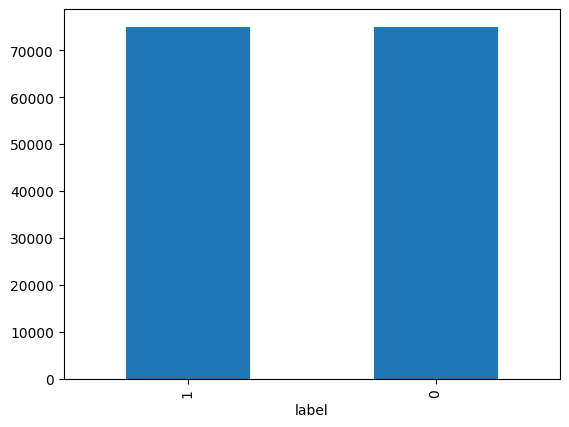

In [30]:
train_data['label'].value_counts().plot(kind = 'bar')

In [32]:
# ============================================
# 📊 학습 데이터의 감성 레이블별 개수 집계
# ============================================

# groupby('label') :
#   label(감성 레이블: 0=부정, 1=긍정)을 기준으로 그룹화
# size() :
#   각 그룹(=각 레이블)의 데이터 개수를 계산
# reset_index(name='count') :
#   결과를 DataFrame 형태로 변환하고, 컬럼명을 'count'로 지정

print(train_data.groupby('label').size().reset_index(name='count'))

   label  count
0      0  74918
1      1  75013


| 변환 전                     | 변환 후                  |
| ------------------------ | --------------------- |
| `"배송 빠르고 good!! 👍👍"`   | `"배송 빠르고 "`           |
| `"가격이 10000원인데 싸네요"`     | `"가격이  원인데 싸네요"`      |
| `"Quality is excellent"` | `""` *(영문만 있는 경우 삭제)* |


In [33]:
# ============================================
# 🧹 텍스트 정제: 한글과 공백만 남기기
# ============================================

# 정규표현식 설명:
# [^ㄱ-ㅎㅏ-ㅣ가-힣 ] → 한글 자모(초성, 중성, 종성)와 공백을 제외한 모든 문자
# str.replace() :
#   문자열 내에서 정규표현식 패턴에 해당하는 부분을 ''(빈 문자열)로 치환
# regex=True :
#   문자열 치환 시 정규표현식을 사용하겠다는 명시적 옵션

train_data['reviews'] = train_data['reviews'].str.replace("[^ㄱ-ㅎㅏ-ㅣ가-힣 ]", "", regex=True)

# 상위 5개 데이터 확인
train_data.head()

,ratings,reviews,label
59666,2,사이즈를 센치씩 늘린건데도 작아요 그리고 색상은 완전 달라요 칙칙한핑크네요ㅠㅠ 많이...,0
12433,2,ㅂ불만족 빗이 아픔 멍이피부에 빗질못해주겟네요,0
146516,1,이 제품쓰고 삼일만에 변기물이 잘 안내려갔어요 혹시나해서 다시 빼보니 물이 다시 잘...,0
158109,5,적당하고 만족합니다,1
70219,2,편하자고 이용하는 밀키튼데 손 은근 많이 가서 저는 패쓰요,0


- 정제 과정 이후 생긴 ‘빈 문자열(’’)’을 결측치(NaN)으로 바꾸고,
각 컬럼별로 결측치 개수를 확인하는 단계

In [34]:
# ============================================
# 🔍 빈 문자열(정제 후 내용이 사라진 리뷰)을 결측치로 처리
# ============================================

# replace('', np.nan, inplace=True)
#  - reviews 열에서 빈 문자열('')을 결측치(NaN)로 변경
#  - inplace=True → 원본 DataFrame(train_data)에 바로 적용

train_data['reviews'].replace('', np.nan, inplace=True)

# ============================================
# 📊 컬럼별 결측치 개수 확인
# ============================================

# isnull() :
#   결측치(True)/정상(False) 판별
# sum() :
#   각 열의 True 개수를 합산하여 결측치 개수 계산

print(train_data.isnull().sum())

ratings    0
reviews    0
label      0
dtype: int64


/tmp/ipython-input-1531766506.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_data['reviews'].replace('', np.nan, inplace=True)


- 테스트 데이터(test_data)에 대한 텍스트 전처리 전체 과정

In [35]:
# ============================================
# 🧹 테스트 데이터 전처리 (중복 제거 + 텍스트 정제 + 결측치 처리)
# ============================================

# 1️⃣ reviews 열에서 중복된 리뷰 제거
#    동일한 리뷰가 여러 번 등장하는 경우 첫 번째만 남기고 삭제
test_data.drop_duplicates(subset=['reviews'], inplace=True)

# 2️⃣ 정규표현식으로 한글과 공백을 제외한 모든 문자 제거
#    예: "good!! 배송 빨라요 ㅎㅎ" → "배송 빨라요 "
test_data['reviews'] = test_data['reviews'].str.replace("[^ㄱ-ㅎㅏ-ㅣ가-힣 ]", "", regex=True)

# 3️⃣ 빈 문자열(내용이 없는 리뷰)을 결측치(NaN)로 변환
test_data['reviews'].replace('', np.nan, inplace=True)

# 4️⃣ 결측치가 존재하는 행 삭제
#    how='any' → 하나라도 NaN이 있으면 해당 행 전체 삭제
test_data = test_data.dropna(how='any')

# 5️⃣ 전처리 완료 후 남은 샘플 개수 출력
print('전처리 후 테스트용 샘플의 개수 :', len(test_data))

전처리 후 테스트용 샘플의 개수 : 49977


/tmp/ipython-input-2204095639.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_data['reviews'].replace('', np.nan, inplace=True)


In [36]:
# ============================================
# 🧩 Kiwipiepy 형태소 분석기 사용 예시
# ============================================

# 1️⃣ 형태소 분석기 불러오기
from kiwipiepy import Kiwi

# 2️⃣ Kiwi 객체 생성
kiwi = Kiwi()

# 3️⃣ 형태소 분석 (morphs = 형태소 단위 분리)
tokens = [token.form for token in kiwi.tokenize('와 이런 것도 상품이라고 차라리 내가 만드는 게 나을 뻔')]

# 4️⃣ 결과 출력
print(tokens)

['와', '이런', '것', '도', '상품', '이', '라고', '차라리', '나', '가', '만들', '는', '것', '이', '낫', '을', '뻔']


In [37]:
stopwords = ['도', '는', '다', '의', '가', '이', '은', '한', '에', '하', '고', '을', '를', '인', '듯', '과', '와', '네', '들', '듯', '지', '임', '게']

In [38]:
# ============================================
# 🧩 형태소 분석 + 불용어 제거 (Kiwipiepy 버전): 약 2분
# ============================================

# 1️⃣ Kiwi 형태소 분석기 불러오기
from kiwipiepy import Kiwi
kiwi = Kiwi()

# 2️⃣ 형태소 분석 함수 정의
def tokenize_kiwi(text):
    # tokenize(): 형태소 단위로 문장을 분리
    # token.form : 형태소 문자열
    return [token.form for token in kiwi.tokenize(text)]

# 3️⃣ 형태소 분석 수행
#    reviews 열의 각 문장에 대해 형태소 분석 결과를 tokenized 열에 저장
train_data['tokenized'] = train_data['reviews'].apply(tokenize_kiwi)

# 4️⃣ 불용어 제거
#    stopwords 리스트에 포함된 단어는 제외
train_data['tokenized'] = train_data['tokenized'].apply(
    lambda tokens: [word for word in tokens if word not in stopwords]
)

In [39]:
# 단어 빈도수 계산을 위한 Counter 불러오기
from collections import Counter

- 부정 리뷰와 긍정 리뷰 각각의 모든 형태소를 하나의 리스트로 합치는 단계

| 변수                   | 내용              | 설명                        |
| -------------------- | --------------- | ------------------------- |
| **`negative_words`** | 부정 리뷰 전체 단어 리스트 | 부정(label=0) 리뷰의 모든 형태소 결합 |
| **`positive_words`** | 긍정 리뷰 전체 단어 리스트 | 긍정(label=1) 리뷰의 모든 형태소 결합 |
| **`np.hstack()`**    | 다차원 배열을 수평으로 연결 | 리뷰별 토큰 리스트를 1차원으로 평탄화     |


In [43]:
# ============================================
# 🧩 긍정/부정 리뷰의 전체 단어(형태소) 통합
# ============================================

import numpy as np

# np.hstack() :
#   여러 리스트(리뷰 단위 형태소 리스트)를 하나의 1차원 배열로 이어붙임
#   즉, [[배송, 느리], [상품, 별로]] → ['배송', '느리', '상품', '별로']

# 부정 리뷰(label == 0)의 모든 단어를 하나의 배열로 합치기
negative_words = np.hstack(train_data[train_data.label == 0]['tokenized'].values)

# 긍정 리뷰(label == 1)의 모든 단어를 하나의 배열로 합치기
positive_words = np.hstack(train_data[train_data.label == 1]['tokenized'].values)

In [44]:
# ============================================
# 🔢 부정 리뷰 단어 빈도 계산
# ============================================

# Counter() :
#   iterable(리스트, 배열 등)의 각 요소 등장 횟수를 자동 계산
#   {'단어': 빈도수} 형태의 딕셔너리 비슷한 객체를 반환

negative_word_count = Counter(negative_words)

# 결과 출력
print(negative_word_count)

Counter({np.str_('었'): 48654, np.str_('어요'): 40300, np.str_('어'): 35280, np.str_('ᆫ'): 35173, np.str_('어서'): 31052, np.str_('네요'): 30894, np.str_('는데'): 21107, np.str_('안'): 19820, np.str_('거'): 16342, np.str_('ᆸ니다'): 14390, np.str_('ᆯ'): 14096, np.str_('너무'): 13472, np.str_('되'): 13229, np.str_('있'): 13184, np.str_('쓰'): 11775, np.str_('나'): 11168, np.str_('것'): 10345, np.str_('좋'): 9489, np.str_('배송'): 9276, np.str_('보'): 9126, np.str_('사'): 9038, np.str_('ᆷ'): 9022, np.str_('같'): 9008, np.str_('오'): 8956, np.str_('구매'): 8811, np.str_('없'): 8686, np.str_('습니다'): 8479, np.str_('기'): 8463, np.str_('그냥'): 8369, np.str_('잘'): 8066, np.str_('않'): 8029, np.str_('시'): 7550, np.str_('주'): 7285, np.str_('요'): 6908, np.str_('만'): 6877, np.str_('로'): 6210, np.str_('별로'): 5647, np.str_('보다'): 5601, np.str_('ᆫ데'): 5560, np.str_('면'): 5558, np.str_('으로'): 5482, np.str_('아니'): 5480, np.str_('겠'): 5411, np.str_('좀'): 5384, np.str_('먹'): 5284, np.str_('제품'): 5108, np.str_('음'): 5108, np.str_('사용'): 5

In [45]:
negative_word_count.most_common(20)

[(np.str_('었'), 48654),
 (np.str_('어요'), 40300),
 (np.str_('어'), 35280),
 (np.str_('ᆫ'), 35173),
 (np.str_('어서'), 31052),
 (np.str_('네요'), 30894),
 (np.str_('는데'), 21107),
 (np.str_('안'), 19820),
 (np.str_('거'), 16342),
 (np.str_('ᆸ니다'), 14390),
 (np.str_('ᆯ'), 14096),
 (np.str_('너무'), 13472),
 (np.str_('되'), 13229),
 (np.str_('있'), 13184),
 (np.str_('쓰'), 11775),
 (np.str_('나'), 11168),
 (np.str_('것'), 10345),
 (np.str_('좋'), 9489),
 (np.str_('배송'), 9276),
 (np.str_('보'), 9126)]

In [46]:
print(negative_word_count.most_common(20))

[(np.str_('었'), 48654), (np.str_('어요'), 40300), (np.str_('어'), 35280), (np.str_('ᆫ'), 35173), (np.str_('어서'), 31052), (np.str_('네요'), 30894), (np.str_('는데'), 21107), (np.str_('안'), 19820), (np.str_('거'), 16342), (np.str_('ᆸ니다'), 14390), (np.str_('ᆯ'), 14096), (np.str_('너무'), 13472), (np.str_('되'), 13229), (np.str_('있'), 13184), (np.str_('쓰'), 11775), (np.str_('나'), 11168), (np.str_('것'), 10345), (np.str_('좋'), 9489), (np.str_('배송'), 9276), (np.str_('보'), 9126)]


In [47]:
positive_word_count = Counter(positive_words) # 파이썬의 Counter 모듈을 이용하면 단어의 모든 빈도를 쉽게 계산할 수 있습니다.
print(positive_word_count)

Counter({np.str_('어요'): 56647, np.str_('좋'): 37451, np.str_('었'): 35296, np.str_('어'): 26239, np.str_('어서'): 21839, np.str_('ᆫ'): 20668, np.str_('네요'): 19578, np.str_('ᆸ니다'): 18670, np.str_('잘'): 18378, np.str_('구매'): 15958, np.str_('습니다'): 13736, np.str_('있'): 12413, np.str_('배송'): 12227, np.str_('는데'): 12105, np.str_('쓰'): 11153, np.str_('ᆯ'): 10468, np.str_('먹'): 9620, np.str_('빠르'): 9480, np.str_('재'): 9110, np.str_('너무'): 8843, np.str_('거'): 8558, np.str_('기'): 7905, np.str_('같'): 7877, np.str_('보'): 7771, np.str_('사'): 7272, np.str_('만족'): 7177, np.str_('되'): 7112, np.str_('것'): 6937, np.str_('사용'): 5826, np.str_('요'): 5224, np.str_('시'): 5176, np.str_('주'): 5016, np.str_('지만'): 4926, np.str_('으로'): 4922, np.str_('가격'): 4847, np.str_('보다'): 4810, np.str_('맛있'): 4692, np.str_('로'): 4617, np.str_('안'): 4586, np.str_('오'): 4368, np.str_('겠'): 4360, np.str_('않'): 4202, np.str_('주문'): 4078, np.str_('제품'): 3971, np.str_('나'): 3952, np.str_('라'): 3893, np.str_('더'): 3639, np.str_('니'): 

In [48]:
positive_word_count.most_common(20)

[(np.str_('어요'), 56647),
 (np.str_('좋'), 37451),
 (np.str_('었'), 35296),
 (np.str_('어'), 26239),
 (np.str_('어서'), 21839),
 (np.str_('ᆫ'), 20668),
 (np.str_('네요'), 19578),
 (np.str_('ᆸ니다'), 18670),
 (np.str_('잘'), 18378),
 (np.str_('구매'), 15958),
 (np.str_('습니다'), 13736),
 (np.str_('있'), 12413),
 (np.str_('배송'), 12227),
 (np.str_('는데'), 12105),
 (np.str_('쓰'), 11153),
 (np.str_('ᆯ'), 10468),
 (np.str_('먹'), 9620),
 (np.str_('빠르'), 9480),
 (np.str_('재'), 9110),
 (np.str_('너무'), 8843)]

In [49]:
print(positive_word_count.most_common(20))

[(np.str_('어요'), 56647), (np.str_('좋'), 37451), (np.str_('었'), 35296), (np.str_('어'), 26239), (np.str_('어서'), 21839), (np.str_('ᆫ'), 20668), (np.str_('네요'), 19578), (np.str_('ᆸ니다'), 18670), (np.str_('잘'), 18378), (np.str_('구매'), 15958), (np.str_('습니다'), 13736), (np.str_('있'), 12413), (np.str_('배송'), 12227), (np.str_('는데'), 12105), (np.str_('쓰'), 11153), (np.str_('ᆯ'), 10468), (np.str_('먹'), 9620), (np.str_('빠르'), 9480), (np.str_('재'), 9110), (np.str_('너무'), 8843)]


긍정 리뷰의 평균 길이 : 14.503965979230268
부정 리뷰의 평균 길이 : 18.840478923623163


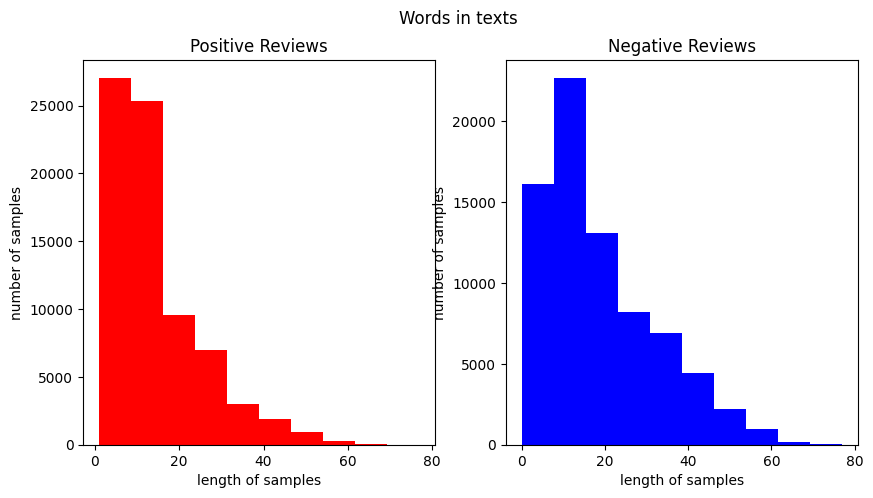

In [50]:
fig,(ax1,ax2) = plt.subplots(1,2,figsize=(10,5))
text_len = train_data[train_data['label']==1]['tokenized'].map(lambda x: len(x))
ax1.hist(text_len, color='red')
ax1.set_title('Positive Reviews')
ax1.set_xlabel('length of samples')
ax1.set_ylabel('number of samples')
print('긍정 리뷰의 평균 길이 :', np.mean(text_len))

text_len = train_data[train_data['label']==0]['tokenized'].map(lambda x: len(x))
ax2.hist(text_len, color='blue')
ax2.set_title('Negative Reviews')
fig.suptitle('Words in texts')
ax2.set_xlabel('length of samples')
ax2.set_ylabel('number of samples')
print('부정 리뷰의 평균 길이 :', np.mean(text_len))
plt.show()

In [51]:
# ============================================
# 🧩 테스트 데이터 형태소 분석 + 불용어 제거
# ============================================

# 1️⃣ Kiwi 형태소 분석기 불러오기
from kiwipiepy import Kiwi
kiwi = Kiwi()

# 2️⃣ 형태소 분석 함수 정의
def tokenize_kiwi(text):
    # tokenize(): 문장을 형태소 단위로 분리
    # token.form : 형태소 문자열
    return [token.form for token in kiwi.tokenize(text)]

# 3️⃣ 형태소 분석 수행
test_data['tokenized'] = test_data['reviews'].apply(tokenize_kiwi)

# 4️⃣ 불용어 제거
#    stopwords 리스트에 포함된 단어는 삭제
test_data['tokenized'] = test_data['tokenized'].apply(
    lambda tokens: [word for word in tokens if word not in stopwords]
)

| 변수          | 내용               | 설명              |
| ----------- | ---------------- | --------------- |
| **X_train** | 학습 데이터의 형태소 리스트  | 입력 데이터          |
| **y_train** | 학습 데이터의 감성 레이블   | 정답 (0=부정, 1=긍정) |
| **X_test**  | 테스트 데이터의 형태소 리스트 | 검증용 입력          |
| **y_test**  | 테스트 데이터의 감성 레이블  | 검증용 정답          |


In [52]:
# ============================================
# 🧩 입력 데이터(X)와 레이블(y) 분리
# ============================================

# 1️⃣ X_train : 학습용 리뷰의 형태소 리스트
#    → 예: [['배송', '빠르', '좋'], ['품질', '별로'], ...]
X_train = train_data['tokenized'].values

# 2️⃣ y_train : 학습용 레이블 (감성 라벨)
#    → 예: [1, 0, 1, 1, 0, ...]
y_train = train_data['label'].values

# 3️⃣ X_test : 테스트용 리뷰의 형태소 리스트
X_test = test_data['tokenized'].values

# 4️⃣ y_test : 테스트용 레이블 (정답)
y_test = test_data['label'].values

In [53]:
X_train[:3]

array([list(['사이즈', '센치', '씩', '늘리', 'ᆫ', '거', 'ᆫ데', '작', '어요', '그리고', '색상', '완전', '다르', '어요', '칙칙', '핑', '크', '네요', 'ㅠㅠ', '많이', '아쉽', '지만', '암', '막', '효과', '좋', '어요']),
       list(['ㅂ', '불', '만족', '빗', '아픔', '멍', '피부', '빗', '질', '못', '어', '주', '겟', '네요']),
       list(['제품', '쓰', '삼', '일', '만', '변기', '물', '잘', '안', '내려가', '었', '어요', '혹시나', '어서', '다시', '빼', '어', '보', '니', '물', '다시', '잘', '내려가', '네요', '많', '거', 'ᆯ', '어쩌', '나요', '반품', '싶'])],
      dtype=object)

In [54]:
y_train[:3]

array([0, 0, 0])

In [55]:
# ============================================
# 🔢 단어 사전(vocabulary) 생성
# ============================================

from tensorflow.keras.preprocessing.text import Tokenizer

# 1️⃣ Tokenizer() 객체 생성
# - 기본 설정으로 단어 빈도순으로 정수 인덱스 부여
tokenizer = Tokenizer()

# 2️⃣ 학습 데이터(X_train)의 형태소 리스트를 학습하여 단어 사전 구축
# - fit_on_texts(): 단어 등장 빈도를 기준으로 단어 인덱스를 자동 생성
# - 예: {'좋': 1, '배송': 2, '빠르': 3, '상품': 4, ...}
tokenizer.fit_on_texts(X_train)

In [56]:
print(tokenizer.word_index)

{'어요': 1, '었': 2, '어': 3, 'ᆫ': 4, '어서': 5, '네요': 6, '좋': 7, '는데': 8, 'ᆸ니다': 9, '잘': 10, '있': 11, '거': 12, '구매': 13, 'ᆯ': 14, '안': 15, '쓰': 16, '너무': 17, '습니다': 18, '배송': 19, '되': 20, '것': 21, '보': 22, '같': 23, '기': 24, '사': 25, '나': 26, '먹': 27, '오': 28, '재': 29, '시': 30, '주': 31, '않': 32, '요': 33, '없': 34, 'ᆷ': 35, '빠르': 36, '사용': 37, '로': 38, '보다': 39, '으로': 40, '만': 41, '겠': 42, '지만': 43, '그냥': 44, '제품': 45, '면': 46, '좀': 47, '생각': 48, 'ᆫ데': 49, '가격': 50, '만족': 51, '주문': 52, '라': 53, '더': 54, '받': 55, '니': 56, '맛': 57, '때': 58, '어야': 59, '많이': 60, '개': 61, '음': 62, '아니': 63, '저': 64, '크': 65, '사이즈': 66, '에서': 67, '별로': 68, '작': 69, 'ㅠㅠ': 70, '두': 71, '그렇': 72, '어도': 73, '맛있': 74, '포장': 75, '수': 76, '못': 77, '세요': 78, '입': 79, '번': 80, '맞': 81, '던': 82, '에요': 83, 'ᆫ지': 84, '엇': 85, '상품': 86, 'ㅠ': 87, '괜찮': 88, '이쁘': 89, '정말': 90, '보내': 91, 'ᆼ': 92, '다른': 93, '싸': 94, '시키': 95, '편하': 96, '넘': 97, '냄새': 98, '부분': 99, '으면': 100, '딱': 101, '감사': 102, '아주': 103, '버리': 104, '서': 105, '예쁘':

| 변수               | 설명                                  |
| ---------------- | ----------------------------------- |
| **`total_cnt`**  | 전체 단어 수 (`tokenizer.word_index` 기준) |
| **`rare_cnt`**   | 등장 빈도 < threshold 인 단어 수            |
| **`total_freq`** | 전체 단어의 등장 횟수 합                      |
| **`rare_freq`**  | 희귀 단어들의 등장 횟수 합                     |
| **`threshold`**  | 희귀 단어의 기준 (2 미만 → 1회 등장 단어)         |


In [57]:
# ============================================
# 🔍 희귀 단어(등장 빈도 낮은 단어) 통계 계산
# ============================================

threshold = 2  # 기준: 등장 빈도 2 미만인 단어를 희귀 단어로 정의

total_cnt = len(tokenizer.word_index)  # 전체 단어 개수
rare_cnt = 0       # 희귀 단어 개수
total_freq = 0     # 전체 단어 등장 횟수
rare_freq = 0      # 희귀 단어 등장 횟수의 합

# 단어와 등장 빈도 쌍을 순회하며 통계 계산
for key, value in tokenizer.word_counts.items():
    total_freq += value  # 전체 단어 등장 횟수 누적

    # 등장 빈도가 threshold 미만인 단어(=희귀 단어)
    if value < threshold:
        rare_cnt += 1
        rare_freq += value

# ============================================
# 📊 결과 출력
# ============================================

print('단어 집합(vocabulary)의 크기 :', total_cnt)
print('등장 빈도가 %s번 이하인 희귀 단어의 수 : %s' % (threshold - 1, rare_cnt))
print("단어 집합에서 희귀 단어의 비율 : %.2f%%" % ((rare_cnt / total_cnt) * 100))
print("전체 등장 빈도에서 희귀 단어 등장 비율 : %.2f%%" % ((rare_freq / total_freq) * 100))

단어 집합(vocabulary)의 크기 : 37794
등장 빈도가 1번 이하인 희귀 단어의 수 : 21160
단어 집합에서 희귀 단어의 비율 : 55.99%
전체 등장 빈도에서 희귀 단어 등장 비율 : 0.85%


In [58]:
# 전체 단어 개수 중 빈도수 2이하인 단어 개수는 제거.
# 0번 패딩 토큰과 1번 OOV 토큰을 고려하여 +2
vocab_size = total_cnt - rare_cnt + 2
print('단어 집합의 크기 :',vocab_size)

단어 집합의 크기 : 16636


| 인자 / 함수                 | 설명                                  |
| ----------------------- | ----------------------------------- |
| `num_words=vocab_size`  | 사용할 최대 단어 개수 (예: 상위 10,000개만 사용)    |
| `oov_token='OOV'`       | 단어 사전에 없는 단어(희귀 단어 등)는 모두 ‘OOV’로 대체 |
| `fit_on_texts(X_train)` | 학습 데이터를 기준으로 단어 인덱스 사전 구축           |
| `texts_to_sequences()`  | 텍스트(형태소 리스트)를 정수 시퀀스로 변환            |


In [59]:
# ============================================
# 🔢 단어 인덱스 생성 + 정수 인코딩
# ============================================

from tensorflow.keras.preprocessing.text import Tokenizer

# 1️⃣ Tokenizer 설정
# - vocab_size : 사용할 단어 수 제한 (희귀 단어 제외한 단어만 사용)
# - oov_token='OOV' : 단어 집합에 없는 단어를 'OOV'(Out Of Vocabulary)로 처리
tokenizer = Tokenizer(num_words=vocab_size, oov_token='OOV')

# 2️⃣ 단어 사전 학습 (훈련 데이터 기반)
tokenizer.fit_on_texts(X_train)

# 3️⃣ 텍스트 데이터를 정수 시퀀스로 변환
# - 각 단어를 단어 인덱스에 해당하는 숫자로 변환
# - 예: ['배송', '빠르', '좋'] → [12, 45, 3]
X_train = tokenizer.texts_to_sequences(X_train)
X_test = tokenizer.texts_to_sequences(X_test)

In [60]:
print(tokenizer.word_index)

{'OOV': 1, '어요': 2, '었': 3, '어': 4, 'ᆫ': 5, '어서': 6, '네요': 7, '좋': 8, '는데': 9, 'ᆸ니다': 10, '잘': 11, '있': 12, '거': 13, '구매': 14, 'ᆯ': 15, '안': 16, '쓰': 17, '너무': 18, '습니다': 19, '배송': 20, '되': 21, '것': 22, '보': 23, '같': 24, '기': 25, '사': 26, '나': 27, '먹': 28, '오': 29, '재': 30, '시': 31, '주': 32, '않': 33, '요': 34, '없': 35, 'ᆷ': 36, '빠르': 37, '사용': 38, '로': 39, '보다': 40, '으로': 41, '만': 42, '겠': 43, '지만': 44, '그냥': 45, '제품': 46, '면': 47, '좀': 48, '생각': 49, 'ᆫ데': 50, '가격': 51, '만족': 52, '주문': 53, '라': 54, '더': 55, '받': 56, '니': 57, '맛': 58, '때': 59, '어야': 60, '많이': 61, '개': 62, '음': 63, '아니': 64, '저': 65, '크': 66, '사이즈': 67, '에서': 68, '별로': 69, '작': 70, 'ㅠㅠ': 71, '두': 72, '그렇': 73, '어도': 74, '맛있': 75, '포장': 76, '수': 77, '못': 78, '세요': 79, '입': 80, '번': 81, '맞': 82, '던': 83, '에요': 84, 'ᆫ지': 85, '엇': 86, '상품': 87, 'ㅠ': 88, '괜찮': 89, '이쁘': 90, '정말': 91, '보내': 92, 'ᆼ': 93, '다른': 94, '싸': 95, '시키': 96, '편하': 97, '넘': 98, '냄새': 99, '부분': 100, '으면': 101, '딱': 102, '감사': 103, '아주': 104, '버리': 105, '서'

In [61]:
print(X_train[:3])

[[67, 1733, 299, 1943, 5, 13, 50, 70, 2, 236, 172, 143, 156, 2, 2562, 2485, 66, 7, 71, 61, 131, 44, 961, 347, 163, 8, 2], [2091, 301, 52, 1976, 3959, 2587, 316, 1976, 313, 78, 4, 32, 448, 7], [46, 17, 985, 113, 42, 1977, 165, 11, 16, 1408, 3, 2, 1200, 6, 127, 257, 4, 23, 57, 165, 127, 11, 1408, 7, 117, 13, 15, 491, 322, 124, 142]]


In [62]:
print(X_test[:3])

[[18, 654, 729, 125, 182, 148, 19], [316, 3188, 61, 777, 2], [20, 37, 7, 51, 178, 8, 22, 24, 2, 469, 223, 4, 27, 115, 394, 57, 11, 7]]


리뷰의 최대 길이 : 77
리뷰의 평균 길이 : 16.67084859035156


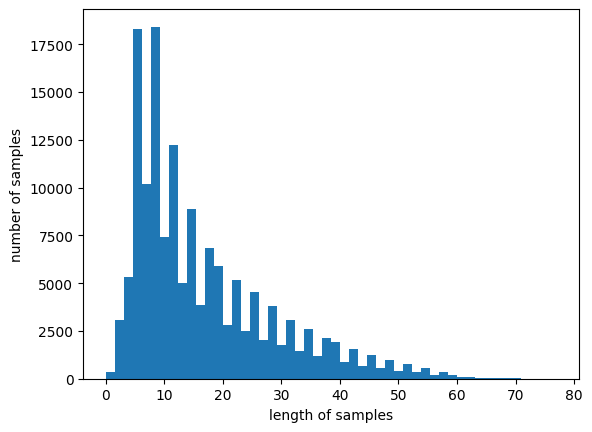

In [63]:
print('리뷰의 최대 길이 :',max(len(l) for l in X_train))
print('리뷰의 평균 길이 :',sum(map(len, X_train))/len(X_train))
plt.hist([len(s) for s in X_train], bins=50)
plt.xlabel('length of samples')
plt.ylabel('number of samples')
plt.show()

In [64]:
def below_threshold_len(max_len, nested_list):
  cnt = 0
  for s in nested_list:
    if(len(s) <= max_len):
        cnt = cnt + 1
  print('전체 샘플 중 길이가 %s 이하인 샘플의 비율: %s'%(max_len, (cnt / len(nested_list))*100))

In [65]:
max_len = 80
below_threshold_len(max_len, X_train)

전체 샘플 중 길이가 80 이하인 샘플의 비율: 100.0


In [66]:
X_train = pad_sequences(X_train, maxlen = max_len)
X_test = pad_sequences(X_test, maxlen = max_len)

In [67]:
X_train.shape

(149931, 80)

In [68]:
X_train[:3]

array([[   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,   67, 1733,
         299, 1943,    5,   13,   50,   70,    2,  236,  172,  143,  156,
           2, 2562, 2485,   66,    7,   71,   61,  131,   44,  961,  347,
         163,    8,    2],
       [   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
        209

# 3. GRU를 이용한 분류

| 구분        | 모듈                | 주요 역할                    |
| --------- | ----------------- | ------------------------ |
| **모델 구조** | `Sequential`      | 층(layer)을 순차적으로 쌓는 기본 모델 |
| **입력 처리** | `Embedding`       | 단어 인덱스를 벡터로 변환 (밀집 표현)   |
| **문맥 학습** | `GRU`             | 시퀀스(문장) 데이터의 시간적 패턴 학습   |
| **출력 처리** | `Dense`           | 완전 연결층 — 분류 결과(긍정/부정) 도출 |
| **학습 관리** | `EarlyStopping`   | 과적합 방지 (성능 향상 멈추면 조기 종료) |
| **모델 저장** | `ModelCheckpoint` | 최고 성능의 모델 자동 저장          |
| **모델 복원** | `load_model`      | 저장된 모델을 다시 불러와 평가/추론 가능  |


In [69]:
# ============================================
# 🧠 GRU 기반 감성분석 모델 구성 관련 모듈 불러오기
# ============================================

# 1️⃣ 모델 구성 관련
from tensorflow.keras.models import Sequential      # 순차적(Sequential) 모델 구조 생성
from tensorflow.keras.layers import Embedding, Dense, GRU
# Embedding : 단어 인덱스를 의미 벡터로 변환 (Word2Vec과 유사한 역할)
# GRU       : 순환 신경망(RNN)의 변형으로, 문맥 정보를 효율적으로 학습
# Dense     : 완전 연결층 (출력층 또는 중간층으로 사용)

# 2️⃣ 학습 관리(콜백 함수)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
# EarlyStopping   : 검증 손실(val_loss)이 개선되지 않으면 학습 조기 종료 (과적합 방지)
# ModelCheckpoint : 학습 중 최고 성능(val_acc 기준) 모델 자동 저장

# 3️⃣ 저장된 모델 불러오기
from tensorflow.keras.models import load_model
# 학습 완료 후 저장된 모델 파일(.h5 / .keras)을 다시 로드하여 재평가 가능

### GRU 기반 감성 분석(긍정/부정 분류) 모델 구성
- 단어 임베딩(Embedding) → 순환 신경망(GRU) → 출력층(Dense)으로 이어지는
가장 기본적이고 효과적인 텍스트 분류용 신경망

| 층 이름                  | 출력 형태                   | 주요 역할         |
| --------------------- | ----------------------- | ------------- |
| **Embedding**         | (batch_size, 문장길이, 100) | 단어를 의미 벡터로 변환 |
| **GRU(128)**          | (batch_size, 128)       | 문맥(순서) 학습     |
| **Dense(1, sigmoid)** | (batch_size, 1)         | 긍정/부정 확률 출력   |


In [70]:
# ============================================
# 🧠 GRU 기반 감성 분석 모델 구성
# ============================================

model = Sequential()  # 층을 순차적으로 쌓는 Sequential 모델 생성

# 1️⃣ Embedding 층
# - 입력: 단어 인덱스 시퀀스 (정수 배열)
# - 출력: 각 단어를 100차원 임베딩 벡터로 변환
# - vocab_size: 사용할 단어 집합 크기
#   → 단어 인덱스 범위는 [0, vocab_size)
model.add(Embedding(vocab_size, 100))

# 2️⃣ GRU 층
# - 128개의 은닉 노드(hidden units)를 가진 GRU 셀
# - 문맥(Context) 정보를 순차적으로 학습 (RNN 계열)
# - 장점: LSTM보다 간단하고 학습 속도가 빠름
model.add(GRU(128))

# 3️⃣ 출력층 (Dense Layer)
# - 노드 수: 1개 (이진 분류)
# - 활성화 함수: sigmoid → 출력값 0~1 사이 확률
# - 0: 부정 리뷰, 1: 긍정 리뷰
model.add(Dense(1, activation='sigmoid'))

- 학습 중 조기 종료(EarlyStopping) 와 최적 모델 자동 저장(ModelCheckpoint)  설정

| 콜백                  | 역할             | 기준 지표      | 종료/저장 조건               |
| ------------------- | -------------- | ---------- | ---------------------- |
| **EarlyStopping**   | 개선이 없을 때 학습 중단 | `val_loss` | 4 epoch 동안 감소하지 않으면 종료 |
| **ModelCheckpoint** | 최고 성능 모델 저장    | `val_acc`  | 정확도가 최고치일 때만 덮어쓰기      |


In [71]:
# ============================================
# 🧩 조기 종료(EarlyStopping) + 최적 모델 저장(ModelCheckpoint)
# ============================================

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# 1️⃣ EarlyStopping 설정
# - 검증 손실(val_loss)이 더 이상 개선되지 않으면 학습 조기 종료
# - patience=4 → 4 epoch 연속으로 성능이 개선되지 않으면 중단
# - mode='min' → 손실(loss)가 낮을수록 좋은 방향
es = EarlyStopping(
    monitor='val_loss',   # 모니터링 대상 (검증 손실)
    mode='min',           # 최소값이 목표
    verbose=1,            # 종료 시 로그 출력
    patience=4            # 개선 없는 epoch 허용 횟수
)

# 2️⃣ ModelCheckpoint 설정
# - 학습 중 검증 정확도(val_acc)가 가장 높을 때의 모델만 저장
# - save_best_only=True → 최고 성능 모델만 파일로 저장
mc = ModelCheckpoint(
    'best_model.h5',      # 저장 파일명
    monitor='val_acc',    # 모니터링 지표 (검증 정확도)
    mode='max',           # 최대값이 목표
    verbose=1,            # 저장 시 로그 출력
    save_best_only=True   # 최고 성능 모델만 저장
)

### GRU 기반 감성분석 모델의 학습 설정(compile)과 실제 학습(fit) 실행 단계

| 항목                   | 설정                    | 설명                                    |
| -------------------- | --------------------- | ------------------------------------- |
| **Optimizer**        | `rmsprop`             | 순환신경망(RNN/GRU/LSTM)에 안정적으로 사용되는 옵티마이저 |
| **Loss**             | `binary_crossentropy` | 감성 분석(이진 분류)에서 사용되는 대표 손실 함수          |
| **Metrics**          | `acc`                 | 정확도(Accuracy) 평가                      |
| **Epochs**           | `15`                  | 전체 데이터셋을 15회 반복 학습                    |
| **Batch size**       | `60`                  | 한 번의 가중치 업데이트에 60개 샘플 사용              |
| **Validation split** | `0.2`                 | 학습 데이터의 20%를 검증용으로 사용                 |
| **Callbacks**        | `[es, mc]`            | 조기 종료 + 최적 모델 자동 저장                   |


In [72]:
# ============================================
# ⚙️ GRU 감성분석 모델 컴파일 & 학습 실행 (약 3분)
# ============================================

# 1️⃣ 모델 컴파일 (학습 방법 정의)
# - optimizer : 가중치 업데이트 방식
# - loss : 예측값과 실제값의 차이를 측정하는 손실 함수
# - metrics : 모델의 성능 평가 지표
model.compile(
    optimizer='rmsprop',             # RNN/GRU 계열에 적합한 안정적 옵티마이저
    loss='binary_crossentropy',      # 이진 분류 손실 함수 (긍정=1, 부정=0)
    metrics=['acc']                  # 정확도(accuracy) 측정
)

# 2️⃣ 모델 학습 (fit)
# - X_train, y_train : 학습 데이터와 레이블
# - epochs : 학습 반복 횟수
# - batch_size : 한 번에 학습할 데이터 개수 (작을수록 세밀한 업데이트)
# - validation_split : 훈련 데이터의 일부(20%)를 검증용으로 사용
# - callbacks : 조기 종료(EarlyStopping) 및 모델 저장(ModelCheckpoint)
history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=60,
    validation_split=0.2,
    callbacks=[es, mc],
    verbose=1  # 학습 과정을 상세 출력
)

Epoch 1/15
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.8527 - loss: 0.3570
Epoch 1: val_acc improved from -inf to 0.91316, saving model to best_model.h5


2000/2000 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - acc: 0.8527 - loss: 0.3570 - val_acc: 0.9132 - val_loss: 0.2400
Epoch 2/15
1998/2000 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9179 - loss: 0.2265
Epoch 2: val_acc improved from 0.91316 to 0.91930, saving model to best_model.h5


2000/2000 ━━━━━━━━━━━━━━━━━━━━ 38s 10ms/step - acc: 0.9179 - loss: 0.2265 - val_acc: 0.9193 - val_loss: 0.2231
Epoch 3/15
1998/2000 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9266 - loss: 0.2061
Epoch 3: val_acc improved from 0.91930 to 0.92283, saving model to best_model.h5


2000/2000 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - acc: 0.9266 - loss: 0.2061 - val_acc: 0.9228 - val_loss: 0.2238
Epoch 4/15
1996/2000 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9312 - loss: 0.1952
Epoch 4: val_acc improved from 0.92283 to 0.92417, saving model to best_model.h5


2000/2000 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - acc: 0.9312 - loss: 0.1952 - val_acc: 0.9242 - val_loss: 0.2096
Epoch 5/15
1999/2000 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9359 - loss: 0.1829
Epoch 5: val_acc did not improve from 0.92417
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - acc: 0.9359 - loss: 0.1829 - val_acc: 0.9165 - val_loss: 0.2254
Epoch 6/15
1999/2000 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9400 - loss: 0.1733
Epoch 6: val_acc improved from 0.92417 to 0.92467, saving model to best_model.h5


2000/2000 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - acc: 0.9400 - loss: 0.1733 - val_acc: 0.9247 - val_loss: 0.2100
Epoch 7/15
1994/2000 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9422 - loss: 0.1692
Epoch 7: val_acc did not improve from 0.92467
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - acc: 0.9422 - loss: 0.1692 - val_acc: 0.9236 - val_loss: 0.2098
Epoch 8/15
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9454 - loss: 0.1612
Epoch 8: val_acc did not improve from 0.92467
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - acc: 0.9454 - loss: 0.1612 - val_acc: 0.9187 - val_loss: 0.2265
Epoch 8: early stopping


In [73]:
loaded_model = load_model('best_model.h5')
print("\n 테스트 정확도: %.4f" % (loaded_model.evaluate(X_test, y_test)[1]))

1562/1562 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - acc: 0.9229 - loss: 0.2124

 테스트 정확도: 0.9222


# 4. 리뷰 예측해보기

- 새로운 리뷰 문장을 입력받아 감성(긍정/부정)을 예측하는 함수

In [74]:
# ============================================
# 💬 새로운 문장 감성 예측 함수 (Kiwipiepy 버전)
# ============================================

from kiwipiepy import Kiwi
kiwi = Kiwi()  # 형태소 분석기 객체 생성

def sentiment_predict(new_sentence):
    """
    새 리뷰 문장을 입력받아
    1️⃣ 텍스트 정제 → 2️⃣ 형태소 분석 → 3️⃣ 불용어 제거 →
    4️⃣ 정수 인코딩 → 5️⃣ 패딩 → 6️⃣ 예측
    의 과정을 거쳐 감성 확률을 출력한다.
    """

    # 1️⃣ 텍스트 정제: 한글과 공백만 남기기
    new_sentence = re.sub(r'[^ㄱ-ㅎㅏ-ㅣ가-힣 ]', '', new_sentence)

    # 2️⃣ 형태소 분석
    new_sentence = [token.form for token in kiwi.tokenize(new_sentence)]

    # 3️⃣ 불용어 제거
    new_sentence = [word for word in new_sentence if word not in stopwords]

    # 4️⃣ 정수 인코딩
    encoded = tokenizer.texts_to_sequences([new_sentence])

    # 5️⃣ 패딩 (학습 시 사용한 max_len과 동일하게)
    pad_new = pad_sequences(encoded, maxlen=max_len)

    # 6️⃣ 예측 (확률값 반환)
    score = float(loaded_model.predict(pad_new))

    # 7️⃣ 결과 출력
    if score > 0.5:
        print("{:.2f}% 확률로 긍정 리뷰입니다.".format(score * 100))
    else:
        print("{:.2f}% 확률로 부정 리뷰입니다.".format((1 - score) * 100))

In [75]:
sentiment_predict('이 상품 진짜 좋아요... 저는 강추합니다. 대박')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
97.74% 확률로 긍정 리뷰입니다.


/tmp/ipython-input-3274917536.py:32: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  score = float(loaded_model.predict(pad_new))


In [76]:
sentiment_predict('진짜 배송도 늦고 개짜증나네요. 뭐 이런 걸 상품이라고 만듬?')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
99.33% 확률로 부정 리뷰입니다.


/tmp/ipython-input-3274917536.py:32: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  score = float(loaded_model.predict(pad_new))


In [77]:
sentiment_predict('판매자님... 너무 짱이에요.. 대박나삼')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
95.51% 확률로 긍정 리뷰입니다.


/tmp/ipython-input-3274917536.py:32: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  score = float(loaded_model.predict(pad_new))


In [78]:
sentiment_predict('ㅁㄴㅇㄻㄴㅇㄻㄴㅇ리뷰쓰기도 귀찮아')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
87.50% 확률로 부정 리뷰입니다.


/tmp/ipython-input-3274917536.py:32: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  score = float(loaded_model.predict(pad_new))


- 모델 학습 과정에서의 손실(loss) 변화를 시각화하는 그래프 그리기
- epoch(훈련 반복 횟수)가 진행되면서 훈련 데이터와 검증 데이터의 손실값이 어떻게 변했는지를 보여줍니다.

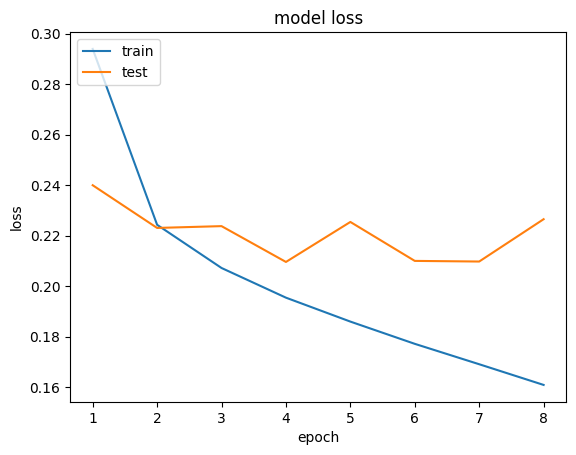

In [79]:
# ============================================
# 📉 학습/검증 손실 시각화
# ============================================

import matplotlib.pyplot as plt

# 1️⃣ 학습 epoch 수만큼의 범위를 생성
epochs = range(1, len(history.history['acc']) + 1)

# 2️⃣ 훈련 손실(loss) 그래프
plt.plot(epochs, history.history['loss'], label='Train Loss')

# 3️⃣ 검증 손실(val_loss) 그래프
plt.plot(epochs, history.history['val_loss'], label='Validation Loss')

# 4️⃣ 그래프 제목, 축 레이블, 범례 설정
plt.title('Model Loss (훈련 vs 검증)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

# 5️⃣ 그래프 출력
plt.show()

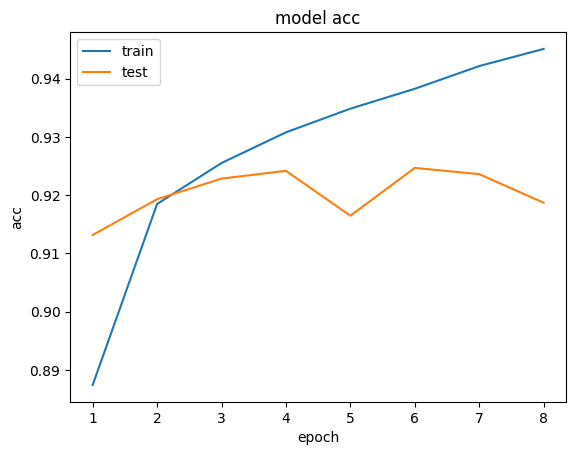

In [80]:
# ============================================
# 📈 학습/검증 정확도(Accuracy) 시각화
# ============================================

import matplotlib.pyplot as plt

# 1️⃣ 학습 반복(epoch) 횟수
epochs = range(1, len(history.history['acc']) + 1)

# 2️⃣ 훈련 정확도 그래프
plt.plot(epochs, history.history['acc'], label='Train Accuracy')

# 3️⃣ 검증 정확도 그래프
plt.plot(epochs, history.history['val_acc'], label='Validation Accuracy')

# 4️⃣ 그래프 제목, 축, 범례 설정
plt.title('Model Accuracy (훈련 vs 검증)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')   # 범례 위치
plt.grid(True)                  # 가독성을 위한 격자 추가

# 5️⃣ 그래프 표시
plt.show()